# Simulation 7 — GLLVM scaling to very high response dimension

ZQE (`ZQEAutoFitter` + parameter-free **Poisson-MAP** encoder) on a **sparse** Poisson
GLLVM, swept across the response dimension $p$ at fixed $q=10$, $n=500$. **No competitor**:
R `gllvm` needs an $O(p^2q^2)$ Hessian and VA/Laplace an intractable $q$-integral, so at
$q=10$ neither can even start here.

Setup mirrors `playground/poisson.ipynb` exactly (only $p$ is swept): `wz_scale=0.5`,
tiny ridge `l2 = 0.001/n`, `lower_tri=True`, sparse loadings (`responses_per_latent=p//2`),
`T=log1p`, **Poisson MAP encoder only** (the Gaussian-log1p MAP explodes / recovers badly
at large $q$).

**The story.** Per-step cost is $O(p)$ FLOPs but ~flat wall-clock on GPU (the $p$ axis is
embarrassingly parallel). Relative loading error (procW) *falls then plateaus*: once the
encoder pins $z$ (~$p\ge1000$ at $q=10$) it hits the **$n$-limited oracle floor** and stays
flat — more loadings *and* more $z$-information, the $\sqrt{p}$ factors cancel in the
relative metric. Crucially it does **not** explode at large $p$.

In [49]:
import os, sys
sys.path.insert(0, os.path.abspath("../../src"))
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else ".")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import highdim
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
print("P_GRID =", highdim.P_GRID, " Q =", highdim.Q, " N =", highdim.N)

P_GRID = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]  Q = 10  N = 500


## Run the sweep

Resumable — each `(p, rep)` writes one tiny CSV under `results/`, and existing ones are
skipped. Launch the full run from a shell so it survives the kernel:

```bash
python -c "import highdim; highdim.run_sweep(reps=20)"
```

or run the cell below (blocks the kernel for the full run).

In [50]:
# highdim.run_sweep(reps=20)   # uncomment to run in-kernel (long)

## Load results

In [51]:
df = highdim.load_results()
df["ratio"] = df.w_hat_norm / df.w_true_norm
print(f"reps/p: {df.groupby('p').rep.nunique().min()}-{df.groupby('p').rep.nunique().max()}"
      f"   p present: {sorted(df.p.unique())}")

summ = (df.groupby("p")
        .agg(procW_med=("procW","median"),
             procW_iqr=("procW", lambda s: s.quantile(.75)-s.quantile(.25)),
             fit_s_med=("fit_s","median"),
             ratio_med=("ratio","median"),
             conv_rate=("converged","mean"))
        .round(3))
summ

reps/p: 2-2   p present: [np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000), np.int64(10000), np.int64(20000), np.int64(50000)]


,procW_med,procW_iqr,fit_s_med,ratio_med,conv_rate
p,,,,,
100,0.205,0.000,18.457,1.004,0.0
200,0.185,0.004,16.798,1.000,0.0
500,0.192,0.007,19.812,1.022,0.0
1000,0.179,0.001,23.473,1.024,0.0
2000,0.183,0.003,29.999,1.004,0.0
5000,0.173,0.002,58.943,1.013,0.0
10000,0.177,0.000,102.429,1.006,0.0
20000,0.173,0.001,181.168,1.009,0.0
50000,0.174,0.001,444.984,0.995,0.0


## Scaling figure

Left: **loading recovery** (procW) vs $p$ — falls to the $n$-limited floor, then flat.
Middle: **wall-clock** vs $p$ — ~flat then gently rising (O(p) FLOPs, GPU-parallel).
Right: **stability** $\|\hat W\|/\|W\|$ vs $p$ — stays ~1, no explosion.

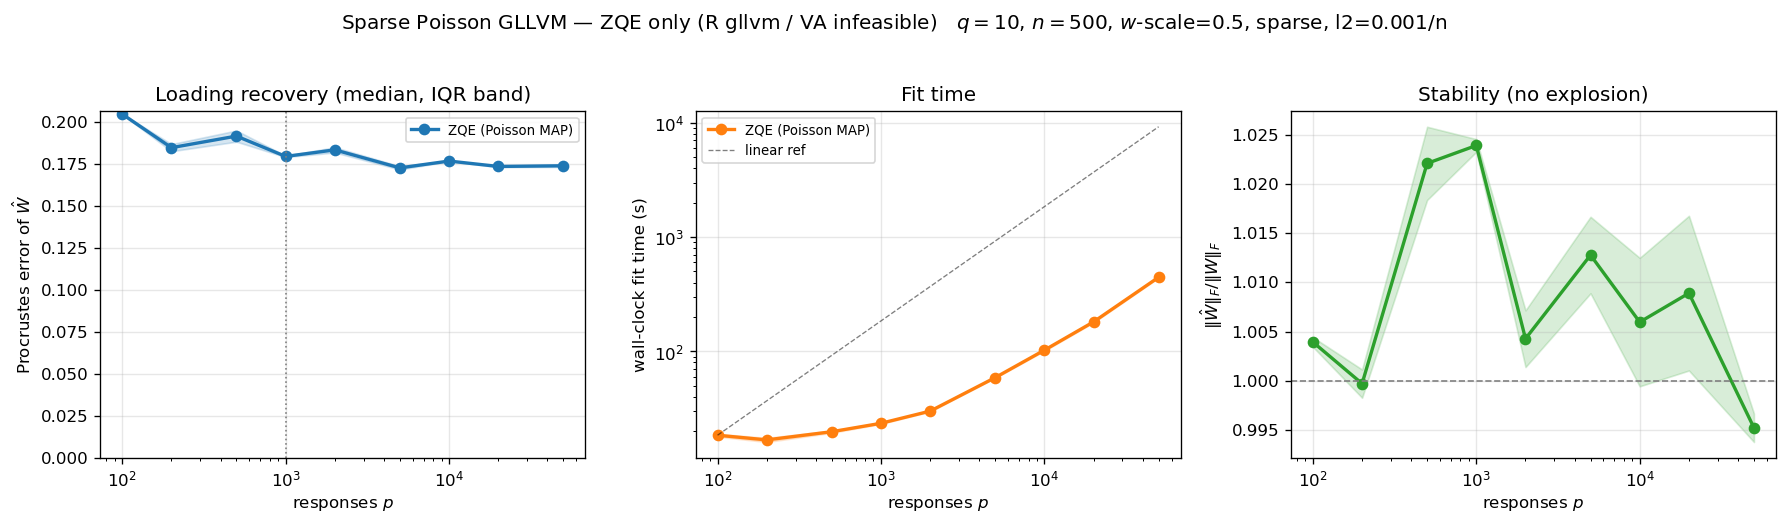

saved paper/figures/highdim_scaling.png


In [52]:
def band(ax, g, col, color, label):
    med = g[col].median(); q1 = g[col].quantile(.25); q3 = g[col].quantile(.75)
    ax.plot(med.index, med.values, "o-", color=color, lw=2, label=label)
    ax.fill_between(med.index, q1.values, q3.values, color=color, alpha=0.18)

g = df.groupby("p")
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

band(ax[0], g, "procW", "#1f77b4", "ZQE (Poisson MAP)")
ax[0].axvline(1000, color="grey", ls=":", lw=1)
ax[0].set_xscale("log"); ax[0].set_xlabel("responses $p$")
ax[0].set_ylabel("Procrustes error of $\\hat W$"); ax[0].set_ylim(bottom=0)
ax[0].set_title("Loading recovery (median, IQR band)"); ax[0].legend(fontsize=8)

band(ax[1], g, "fit_s", "#ff7f0e", "ZQE (Poisson MAP)")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("responses $p$"); ax[1].set_ylabel("wall-clock fit time (s)")
p0, t0 = g.fit_s.median().index[0], g.fit_s.median().values[0]
pr = np.array(sorted(df.p.unique()))
ax[1].plot(pr, t0 * pr / p0, "k--", lw=0.8, alpha=0.5, label="linear ref")
ax[1].set_title("Fit time"); ax[1].legend(fontsize=8)

band(ax[2], g, "ratio", "#2ca02c", "ZQE (Poisson MAP)")
ax[2].axhline(1.0, color="grey", ls="--", lw=1)
ax[2].set_xscale("log"); ax[2].set_xlabel("responses $p$")
ax[2].set_ylabel(r"$\|\hat W\|_F / \|W\|_F$")
ax[2].set_title("Stability (no explosion)")

fig.suptitle(f"Sparse Poisson GLLVM — ZQE only (R gllvm / VA infeasible)   "
             f"$q={highdim.Q}$, $n={highdim.N}$, $w$-scale=0.5, sparse, l2=0.001/n", y=1.03)
fig.tight_layout()
os.makedirs("../../paper/figures", exist_ok=True)
fig.savefig("../../paper/figures/highdim_scaling.png", dpi=140, bbox_inches="tight")
plt.show()
print("saved paper/figures/highdim_scaling.png")